In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv("air_fryers_clean_brand_year.csv")

In [2]:
df["log_brand_share"] = np.log(df["brand_share"])

print(df[["year", "brand", "brand_share", "log_brand_share", "avg_price", "avg_rating"]].head())

   year       brand  brand_share  log_brand_share   avg_price  avg_rating
0  2019     chefman     0.076015        -2.576826   72.963695    4.434119
1  2019      cosori     0.000730        -7.222964  159.990000    4.581818
2  2019   cuisinart     0.107190        -2.233150  229.465274    4.481312
3  2019        dash     0.199721        -1.610832   55.176333    4.390767
4  2019  gowise usa     0.292186        -1.230364   83.575551    4.552259


In [3]:
feature_cols = [
    "avg_price",
    "avg_rating",
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

brand_dummies = pd.get_dummies(df["brand"], prefix="brand", drop_first=True)
year_dummies = pd.get_dummies(df["year"], prefix="year", drop_first=True)

X = pd.concat([df[feature_cols], brand_dummies, year_dummies], axis=1)
X = X.astype(float)

y = df["log_brand_share"].astype(float)

print(X.head())
print("\nX shape:", X.shape)
print("y shape:", y.shape)

    avg_price  avg_rating  compact_share  dual_basket_share  oven_style_share  \
0   72.963695    4.434119       1.000000                0.0          0.780977   
1  159.990000    4.581818       1.000000                0.0          0.090909   
2  229.465274    4.481312       0.993812                0.0          0.889851   
3   55.176333    4.390767       1.000000                0.0          0.973431   
4   83.575551    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  brand_cosori  brand_cuisinart  brand_dash  \
0          0.243455      0.184119           0.0              0.0         0.0   
1          0.090909      0.000000           1.0              0.0         0.0   
2          0.000000      0.000000           0.0              1.0         0.0   
3          0.000000      0.000000           0.0              0.0         1.0   
4          0.128490      0.000000           0.0              0.0         0.0   

   brand_gowise usa  brand_insta

In [4]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        log_brand_share   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     4.680
Date:                Tue, 05 May 2026   Prob (F-statistic):           9.24e-05
Time:                        14:01:13   Log-Likelihood:                -36.451
No. Observations:                  50   AIC:                             114.9
Df Residuals:                      29   BIC:                             155.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.3049     16.28

In [5]:
beta_price = model.params["avg_price"]
print("Estimated price coefficient:", beta_price)

Estimated price coefficient: -0.03766765298429452


In [6]:
df["demand_slope"] = beta_price * df["brand_share"] * (1 - df["brand_share"])
df["unit_cost"] = df["avg_price"] + df["brand_share"] / df["demand_slope"]
df["markup"] = df["avg_price"] - df["unit_cost"]
df["average_profit"] = df["brand_share"] * df["markup"]

print(df[["year", "brand", "avg_price", "brand_share", "demand_slope", "unit_cost", "markup", "average_profit"]].head())

   year       brand   avg_price  brand_share  demand_slope   unit_cost  \
0  2019     chefman   72.963695     0.076015     -0.002646   44.231656   
1  2019      cosori  159.990000     0.000730     -0.000027  133.422638   
2  2019   cuisinart  229.465274     0.107190     -0.003605  199.729962   
3  2019        dash   55.176333     0.199721     -0.006021   22.002913   
4  2019  gowise usa   83.575551     0.292186     -0.007790   46.068541   

      markup  average_profit  
0  28.732039        2.184062  
1  26.567362        0.019385  
2  29.735313        3.187335  
3  33.173420        6.625442  
4  37.507010       10.959033  


In [7]:
beta_price = model.params["avg_price"]

df["demand_slope"] = beta_price * df["brand_share"] * (1 - df["brand_share"])
df["unit_cost"] = df["avg_price"] + df["brand_share"] / df["demand_slope"]
df["markup"] = df["avg_price"] - df["unit_cost"]
df["average_profit"] = df["brand_share"] * df["markup"]

print(df[["year", "brand", "avg_price", "brand_share", "demand_slope", "unit_cost", "markup", "average_profit"]].head())

   year       brand   avg_price  brand_share  demand_slope   unit_cost  \
0  2019     chefman   72.963695     0.076015     -0.002646   44.231656   
1  2019      cosori  159.990000     0.000730     -0.000027  133.422638   
2  2019   cuisinart  229.465274     0.107190     -0.003605  199.729962   
3  2019        dash   55.176333     0.199721     -0.006021   22.002913   
4  2019  gowise usa   83.575551     0.292186     -0.007790   46.068541   

      markup  average_profit  
0  28.732039        2.184062  
1  26.567362        0.019385  
2  29.735313        3.187335  
3  33.173420        6.625442  
4  37.507010       10.959033  


In [8]:
brand_cost_markup_summary = (
    df.groupby("brand")
      .agg(
          avg_unit_cost=("unit_cost", "mean"),
          avg_markup=("markup", "mean"),
          avg_profit=("average_profit", "mean"),
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean")
      )
      .sort_values("avg_unit_cost", ascending=False)
)

print(brand_cost_markup_summary.round(3))

             avg_unit_cost  avg_markup  avg_profit  avg_price  avg_rating
brand                                                                    
cuisinart          194.896      29.051       2.503    223.947       4.439
oster              161.805      27.226       0.678    189.031       4.389
ninja              112.488      32.854       6.306    145.343       4.742
nuwave             109.054      27.971       1.423    137.024       4.390
cosori              86.283      27.985       1.437    114.268       4.656
instant_pot         71.903      32.558       6.010    104.461       4.559
chefman             61.569      29.369       2.821     90.938       4.428
gowise usa          56.301      31.154       4.606     87.455       4.577
ultrean             48.786      29.329       2.781     78.115       4.673
dash                27.937      29.542       2.994     57.479       4.476


In [9]:
negative_costs = df[df["unit_cost"] < 0][["year", "brand", "unit_cost", "avg_price", "brand_share", "demand_slope"]]
print(negative_costs)
print("\nNumber of negative inferred unit costs:", (df["unit_cost"] < 0).sum())

Empty DataFrame
Columns: [year, brand, unit_cost, avg_price, brand_share, demand_slope]
Index: []

Number of negative inferred unit costs: 0


In [10]:
highest_cost_brands = brand_cost_markup_summary.sort_values("avg_unit_cost", ascending=False)
print(highest_cost_brands[["avg_unit_cost", "avg_price", "avg_rating"]].round(3))

             avg_unit_cost  avg_price  avg_rating
brand                                            
cuisinart          194.896    223.947       4.439
oster              161.805    189.031       4.389
ninja              112.488    145.343       4.742
nuwave             109.054    137.024       4.390
cosori              86.283    114.268       4.656
instant_pot         71.903    104.461       4.559
chefman             61.569     90.938       4.428
gowise usa          56.301     87.455       4.577
ultrean             48.786     78.115       4.673
dash                27.937     57.479       4.476


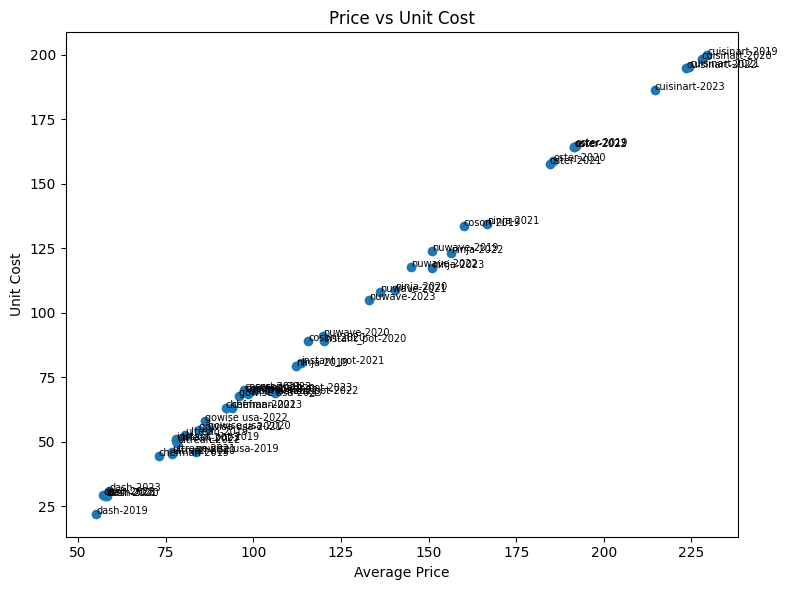

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df["avg_price"], df["unit_cost"])

for _, row in df.iterrows():
    plt.text(row["avg_price"], row["unit_cost"], f"{row['brand']}-{row['year']}", fontsize=7)

plt.xlabel("Average Price")
plt.ylabel("Unit Cost")
plt.title("Price vs Unit Cost")
plt.tight_layout()
plt.show()

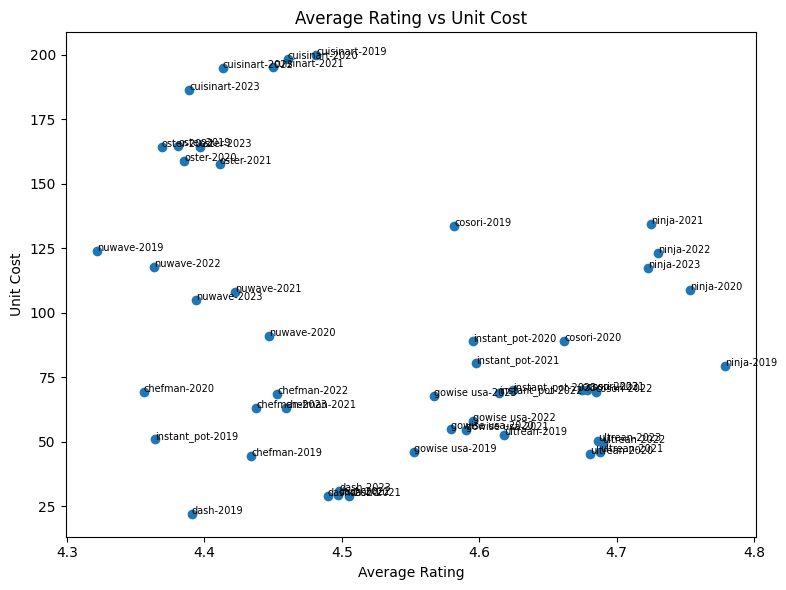

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(df["avg_rating"], df["unit_cost"])

for _, row in df.iterrows():
    plt.text(row["avg_rating"], row["unit_cost"], f"{row['brand']}-{row['year']}", fontsize=7)

plt.xlabel("Average Rating")
plt.ylabel("Unit Cost")
plt.title("Average Rating vs Unit Cost")
plt.tight_layout()
plt.show()

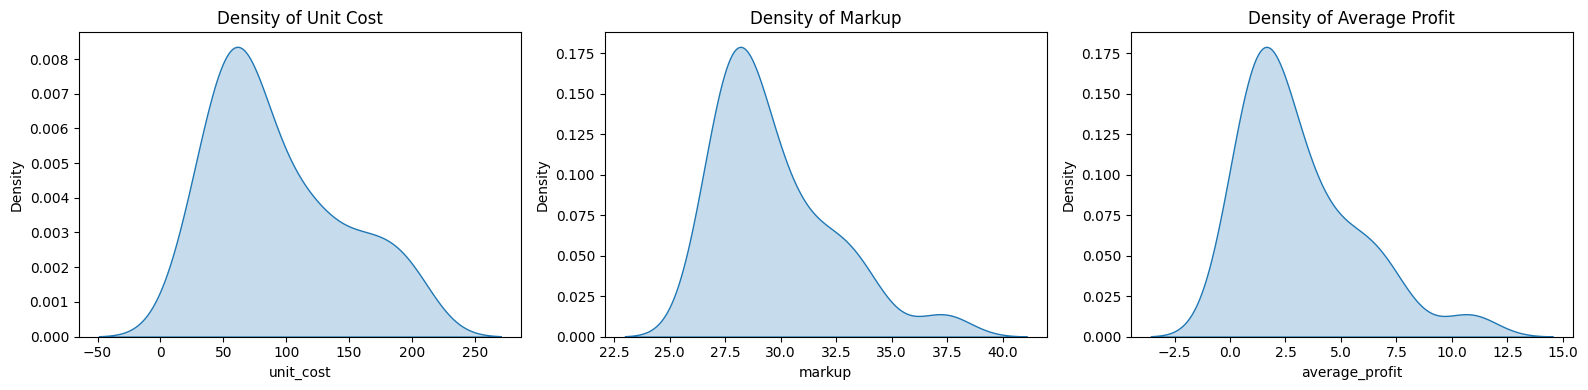

In [13]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.kdeplot(data=df, x="unit_cost", fill=True, ax=axes[0])
axes[0].set_title("Density of Unit Cost")

sns.kdeplot(data=df, x="markup", fill=True, ax=axes[1])
axes[1].set_title("Density of Markup")

sns.kdeplot(data=df, x="average_profit", fill=True, ax=axes[2])
axes[2].set_title("Density of Average Profit")

plt.tight_layout()
plt.show()

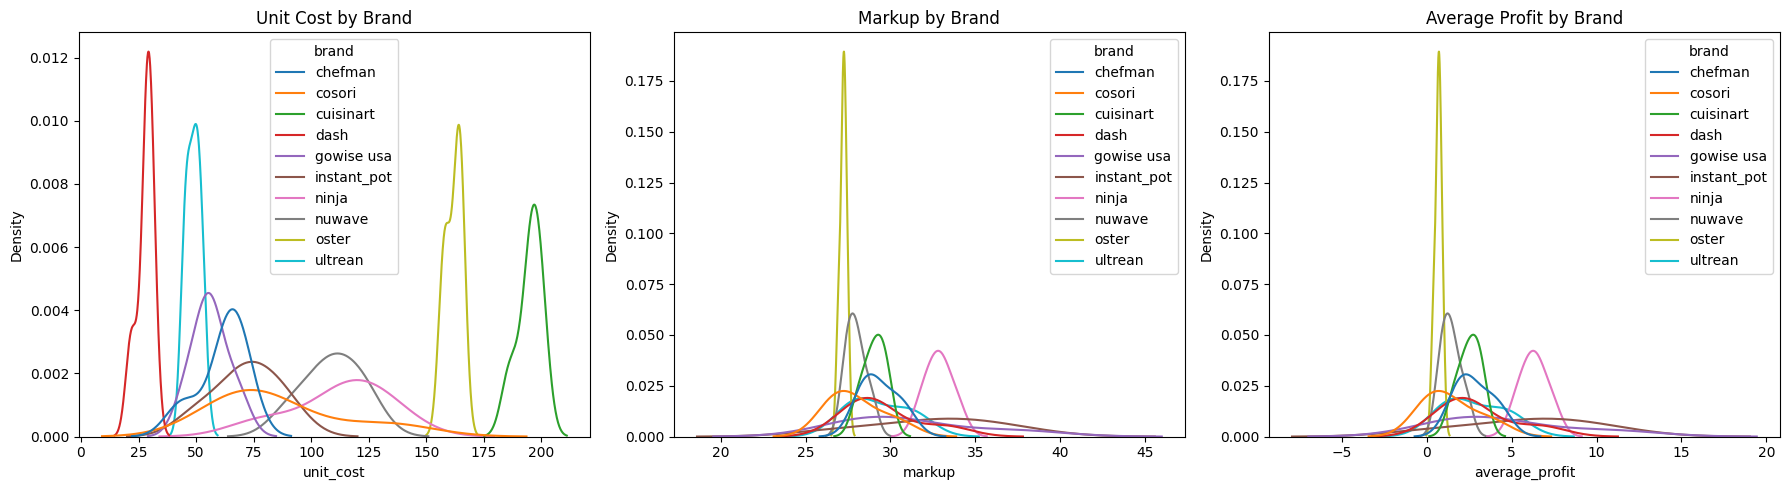

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(data=df, x="unit_cost", hue="brand", ax=axes[0])
axes[0].set_title("Unit Cost by Brand")

sns.kdeplot(data=df, x="markup", hue="brand", ax=axes[1])
axes[1].set_title("Markup by Brand")

sns.kdeplot(data=df, x="average_profit", hue="brand", ax=axes[2])
axes[2].set_title("Average Profit by Brand")

plt.tight_layout()
plt.show()

In [15]:
profit_by_brand = (
    df.groupby("brand")
      .agg(
          avg_share_weighted_profit=("average_profit", "mean"),
          avg_markup=("markup", "mean"),
          avg_unit_cost=("unit_cost", "mean")
      )
      .sort_values("avg_share_weighted_profit", ascending=False)
)

print(profit_by_brand.round(3))

             avg_share_weighted_profit  avg_markup  avg_unit_cost
brand                                                            
ninja                            6.306      32.854        112.488
instant_pot                      6.010      32.558         71.903
gowise usa                       4.606      31.154         56.301
dash                             2.994      29.542         27.937
chefman                          2.821      29.369         61.569
ultrean                          2.781      29.329         48.786
cuisinart                        2.503      29.051        194.896
cosori                           1.437      27.985         86.283
nuwave                           1.423      27.971        109.054
oster                            0.678      27.226        161.805


In [16]:
summary_table = (
    df.groupby("brand")
      .agg(
          avg_unit_cost=("unit_cost", "mean"),
          avg_markup=("markup", "mean"),
          avg_share_weighted_profit=("average_profit", "mean"),
          avg_price=("avg_price", "mean"),
          avg_rating=("avg_rating", "mean")
      )
      .sort_values("avg_share_weighted_profit", ascending=False)
)

print(summary_table.round(3))

             avg_unit_cost  avg_markup  avg_share_weighted_profit  avg_price  \
brand                                                                          
ninja              112.488      32.854                      6.306    145.343   
instant_pot         71.903      32.558                      6.010    104.461   
gowise usa          56.301      31.154                      4.606     87.455   
dash                27.937      29.542                      2.994     57.479   
chefman             61.569      29.369                      2.821     90.938   
ultrean             48.786      29.329                      2.781     78.115   
cuisinart          194.896      29.051                      2.503    223.947   
cosori              86.283      27.985                      1.437    114.268   
nuwave             109.054      27.971                      1.423    137.024   
oster              161.805      27.226                      0.678    189.031   

             avg_rating  
brand        

1. What are the average unit costs and markups for each brand over the years?

Cuisinart and Oster have the highest average unit costs. Dash and Ultrean have the lowest. Markups are more similar across brands, with Ninja and Instant Pot among the highest.

2. Are any inferred unit costs negative? If so, what might that mean?

No. There are no negative inferred unit costs, which suggests the cost estimates are reasonable.

3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Do more expensive products have higher consumer satisfaction?

Cuisinart, Oster, and Ninja have the highest average unit costs. Higher cost does not always mean higher ratings, although Ninja performs well on both.

4. kernel density plots of unit costs, markups, and average profit, in general and hued by brand.

Unit costs vary a lot across brands. Markups are more tightly grouped. Average profit is skewed, with a few brand-years much higher than the rest.

5. Which brands have the highest share-weighted average profit?

Ninja, Instant Pot, and GoWise USA have the highest average share-weighted profit.